# transformer

--- 1. Début du Chargement du Domaine 2 ---
Dossier source : \\student.fucam.ac.be\users$\isadiki\Downloads\Domain2base\DOMAIN2_CSVcorrigé
Nombre total d'observations chargées : 79866


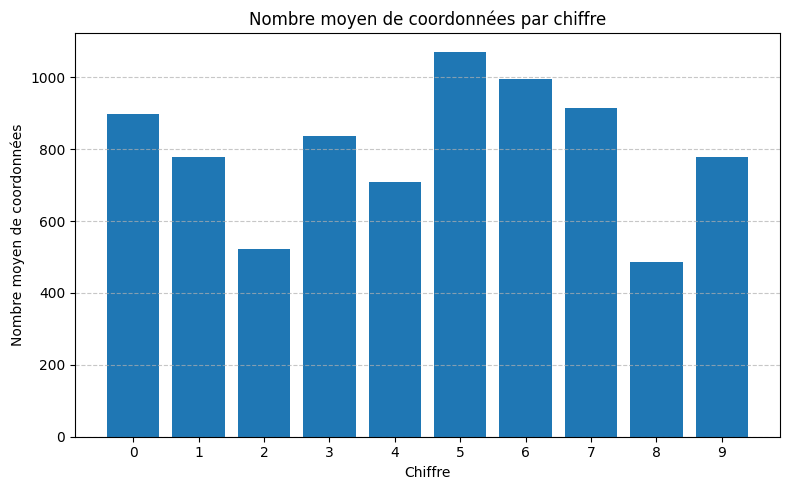

Chiffre 0 : 3980.00 s
Chiffre 1 : 3567.20 s
Chiffre 2 : 2570.50 s
Chiffre 3 : 4037.70 s
Chiffre 4 : 3087.10 s
Chiffre 5 : 5395.70 s
Chiffre 6 : 4499.00 s
Chiffre 7 : 4250.90 s
Chiffre 8 : 2463.70 s
Chiffre 9 : 3477.00 s


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_16848\2611384756.py:108: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



--- Test subject OUT : 1 ---

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 224ms/step - accuracy: 0.0967 - loss: 2.4345
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 245ms/step - accuracy: 0.1989 - loss: 2.1510
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 256ms/step - accuracy: 0.7322 - loss: 0.7452
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 256ms/step - accuracy: 0.8500 - loss: 0.4441
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 253ms/step - accuracy: 0.9522 - loss: 0.1556
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 234ms/step - accuracy: 0.9644 - loss: 0.1257
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 228ms/step - accuracy: 0.9856 - loss: 0.0668
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 227ms/step - accuracy: 0.9833 - loss: 0.0431
Epoch 9/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 226ms/step - accuracy: 0.9911 - loss: 0.0314
Epoch 10/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 228ms/step - accuracy: 0.9667 - loss: 0.1039
Epoch 11/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 227ms/step - accuracy: 0.9722 - loss: 0.0852
Epoch 12/50
29/29 ━━

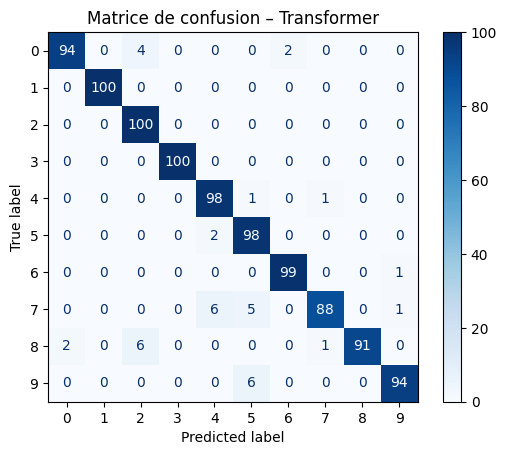

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf



DOMAIN_FOLDER =r"\\student.fucam.ac.be\users$\isadiki\Downloads\Domain2base\DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2


df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:

                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2: continue


                data = file[0].str.strip('"').str.split(',', expand=True)

                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])


                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)


                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df_list.append(file_df)

            except FileNotFoundError:
                continue
            except Exception:
                continue


if not df_list:
    raise ValueError("Aucun fichier n'a pu être chargé. Vérifiez le chemin et le format des fichiers.")

df = pd.concat(df_list, ignore_index=True)

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Nombre total d'observations chargées : {len(df)}")


grouped = df.groupby(['gesture', 'iter'])
sequence_lengths = grouped.size().reset_index(name='length')
mean_lengths = sequence_lengths.groupby('gesture')['length'].mean().reset_index()
mean_lengths.columns = ['Chiffre', 'Frames moyennes']

plt.figure(figsize=(8, 5))
plt.bar(mean_lengths["Chiffre"], mean_lengths["Frames moyennes"])
plt.title("Nombre moyen de coordonnées par chiffre")
plt.xlabel("Chiffre")
plt.ylabel("Nombre moyen de coordonnées")
plt.xticks(mean_lengths["Chiffre"])
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

durations = df.groupby(['gesture', 'iter'])['t'].agg(lambda x: x.max() - x.min()).reset_index(name='duration')
mean_durations = durations.groupby('gesture')['duration'].mean()
for gesture, mean_dur in mean_durations.items():
    print(f"Chiffre {gesture} : {mean_dur:.2f} s")




def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        if std == 0 or np.isnan(std):
            df_copy[f'{axis}_std'] = 0.0
        else:
            df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)




def resample_gesture(df_in, target_len=100):
    resampled_data = []

    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue

        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))

    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)




def create_user_independent_split(df_in, subj_out):
    train_df = df_in[df_in['subject'] != subj_out]
    test_df = df_in[df_in['subject'] == subj_out]

    def df_to_array(df_target):
        X, y = [], []
        for (gesture, subject, iteration), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(gesture)
        return np.array(X), np.array(y)

    X_train, y_train = df_to_array(train_df)
    X_test, y_test = df_to_array(test_df)
    return X_train, y_train, X_test, y_test




class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]




def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)

    ffn = models.Sequential([
        layers.Dense(dff, activation="relu"),
        layers.Dense(d_model),
    ])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    out2 = layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)
    return out2

def create_transformer_model(input_shape, num_classes, seq_len=100):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2

    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(seq_len, d_model)(x)

    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model




def test_transformer_user_independent(df_data, loop_range=10, epochs=30, batch_size=32, verbose_fit=1):
    total_true, total_pred = [], []

    for subj_out in range(1, loop_range + 1):
        if df_data[df_data['subject'] == subj_out].empty: continue

        print(f"\n--- Test subject OUT : {subj_out} ---")
        X_train, y_train, X_test, y_test = create_user_independent_split(df_data, subj_out)

        n_classes = len(np.unique(df_data['gesture']))
        input_shape = (X_train.shape[1], X_train.shape[2])

        model = create_transformer_model(input_shape=input_shape, num_classes=n_classes)
        model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=verbose_fit)

        y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        acc = accuracy_score(y_test, y_pred)
        print(f"Exactitude subject {subj_out} : {acc:.2%}")

        total_true.extend(y_test)
        total_pred.extend(y_pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\nExactitude globale Transformer : {final_acc:.2%}")

    cm = confusion_matrix(total_true, total_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title("Matrice de confusion – Transformer")
    plt.show()


test_transformer_user_independent(df100, loop_range=10, epochs=50, batch_size=32, verbose_fit=1)

# lstm

--- 1. Début du Chargement du Domaine 2 ---
Dossier source : \\student.fucam.ac.be\users$\isadiki\Downloads\Domain2base\DOMAIN2_CSVcorrigé
✅ Nombre total d'observations chargées : 79866

--- 2. Analyse Exploratoire ---


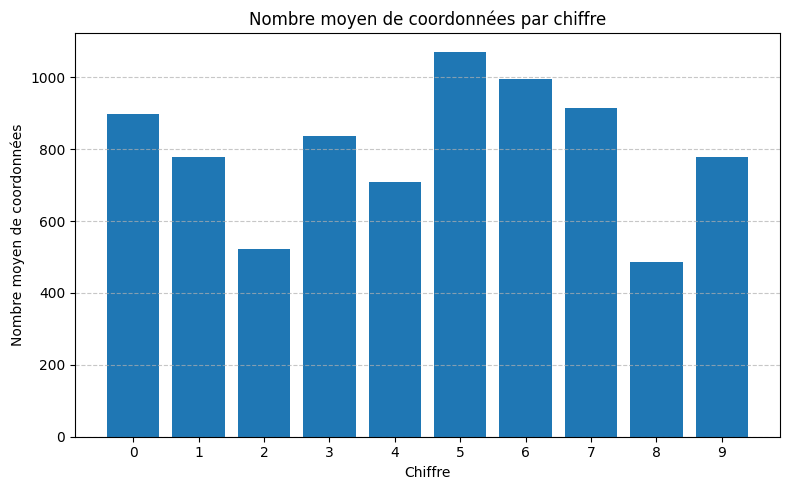

Chiffre 0 : 3980.00 s
Chiffre 1 : 3567.20 s
Chiffre 2 : 2570.50 s
Chiffre 3 : 4037.70 s
Chiffre 4 : 3087.10 s
Chiffre 5 : 5395.70 s
Chiffre 6 : 4499.00 s
Chiffre 7 : 4250.90 s
Chiffre 8 : 2463.70 s
Chiffre 9 : 3477.00 s

Standardisation...


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_18748\2095607127.py:105: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling à longueur 100...

--- Test subject OUT : 1 ---


\\student.fucam.ac.be\users$\isadiki\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Exactitude subject 1 : 98.00%

--- Test subject OUT : 2 ---


...

Exactitude subject 8 : 95.00%

--- Test subject OUT : 9 ---


\\student.fucam.ac.be\users$\isadiki\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Exactitude subject 9 : 98.00%

--- Test subject OUT : 10 ---


\\student.fucam.ac.be\users$\isadiki\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Exactitude subject 10 : 98.00%

Exactitude globale LSTM : 96.70%


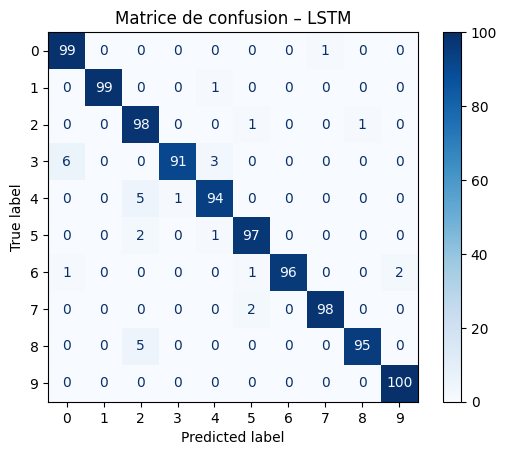

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers




DOMAIN_FOLDER = r"\\student.fucam.ac.be\users$\isadiki\Downloads\Domain2base\DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:

                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2: continue


                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])


                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)


                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df_list.append(file_df)

            except (FileNotFoundError, Exception):
                continue


if not df_list:
    raise ValueError(" Aucun fichier n'a été chargé. Vérifiez le chemin : " + DOMAIN_FOLDER)

df = pd.concat(df_list, ignore_index=True)


for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f" Nombre total d'observations chargées : {len(df)}")



print("\n--- 2. Analyse Exploratoire ---")
grouped = df.groupby(['gesture', 'iter'])
sequence_lengths = grouped.size().reset_index(name='length')
mean_lengths = sequence_lengths.groupby('gesture')['length'].mean().reset_index()
mean_lengths.columns = ['Chiffre', 'Frames moyennes']

plt.figure(figsize=(8, 5))
plt.bar(mean_lengths["Chiffre"], mean_lengths["Frames moyennes"])
plt.title("Nombre moyen de coordonnées par chiffre")
plt.xlabel("Chiffre")
plt.ylabel("Nombre moyen de coordonnées")
plt.xticks(mean_lengths["Chiffre"])
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

durations = df.groupby(['gesture', 'iter'])['t'].agg(lambda x: x.max() - x.min()).reset_index(name='duration')
mean_durations = durations.groupby('gesture')['duration'].mean()
for gesture, mean_dur in mean_durations.items():
    print(f"Chiffre {gesture} : {mean_dur:.2f} s")



def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        if std == 0 or np.isnan(std):
            df_copy[f'{axis}_std'] = 0.0
        else:
            df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std
    return df_copy

print("\nStandardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling à longueur 100...")
df100 = resample_gesture(df)



def create_user_independent_split(df_in, subj_out):
    train_df = df_in[df_in['subject'] != subj_out]
    test_df = df_in[df_in['subject'] == subj_out]

    def df_to_array(df_target):
        X, y = [], []
        for (gesture, subject, iteration), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(gesture)
        return np.array(X), np.array(y)

    X_train, y_train = df_to_array(train_df)
    X_test, y_test = df_to_array(test_df)
    return X_train, y_train, X_test, y_test



def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, dropout=0.2, input_shape=input_shape),
        layers.LSTM(256, dropout=0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model



def test_lstm_user_independent(df_data, loop_range=10, epochs=50, batch_size=16):
    total_true, total_pred = [], []
    subjects = sorted(df_data['subject'].unique())

    for subj_out in subjects:
        print(f"\n--- Test subject OUT : {subj_out} ---")
        X_train, y_train, X_test, y_test = create_user_independent_split(df_data, subj_out)


        all_labels = np.unique(df_data['gesture'])
        num_classes = int(max(all_labels) + 1)

        model = create_lstm_model(input_shape=(X_train.shape[1], X_train.shape[2]), num_classes=num_classes)


        model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)


        y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        acc = accuracy_score(y_test, y_pred)
        print(f"Exactitude subject {subj_out} : {acc:.2%}")

        total_true.extend(y_test)
        total_pred.extend(y_pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\nExactitude globale LSTM : {final_acc:.2%}")


    cm = confusion_matrix(total_true, total_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title("Matrice de confusion – LSTM")
    plt.show()


test_lstm_user_independent(df100)

# edit distance dans cluster corssvalide

--- Début du Chargement ---
Dossier source : \\student.fucam.ac.be\users$\isadiki\Downloads\Domain2base\DOMAIN2_CSVcorrigé


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_17552\221923040.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Nombre total d'observations chargées : 79866
Standardisation des données...


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_17552\221923040.py:73: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture)


Resampling à 100 points...
Test sur sujet sorti : 1
Précision split : 99.00%
Test sur sujet sorti : 2
Précision split : 88.00%
Test sur sujet sorti : 3
Précision split : 95.00%
Test sur sujet sorti : 4
Précision split : 96.00%
Test sur sujet sorti : 5
Précision split : 87.00%
Test sur sujet sorti : 6
Précision split : 93.00%
Test sur sujet sorti : 7
Précision split : 92.00%
Test sur sujet sorti : 8
Précision split : 80.00%
Test sur sujet sorti : 9
Précision split : 98.00%
Test sur sujet sorti : 10
Précision split : 96.00%

=== EXACTITUDE GLOBALE : 92.40% ===


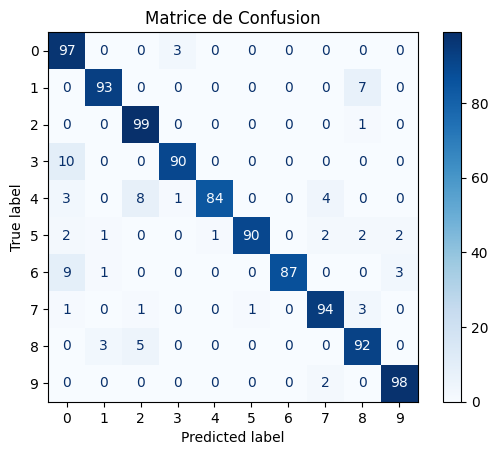

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d




DOMAIN_FOLDER = r"\\student.fucam.ac.be\users$\isadiki\Downloads\Domain2base\DOMAIN2_CSVcorrigé"

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:

                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue


                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])


                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)


                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df = pd.concat([df, file_df], ignore_index=True)

            except FileNotFoundError:
                continue
            except Exception:
                continue

print(f"Nombre total d'observations chargées : {len(df)}")


for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)



def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f"{axis}_std"] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation des données...")
df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    groups = df_input.groupby(["gesture", "subject", "iter"])

    for (gesture, subject, iteration), group in groups:
        n = len(group)
        if n < 2: continue

        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)

        res_dict = {
            "gesture": [gesture]*target_len,
            "subject": [subject]*target_len,
            "iter": [iteration]*target_len
        }

        for col in ["x_std", "y_std", "z_std"]:
            res_dict[col] = interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame(res_dict))

    return pd.concat(resampled_data, ignore_index=True)

print("Resampling à 100 points...")
df100 = resample_gesture(df)



def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def gesture_to_sequence(df_sym):
    seq_dict = defaultdict(list)
    for (gesture, subject, iteration), group in df_sym.groupby(["gesture", "subject", "iter"]):
        seq = "".join(group["symbol"].tolist())
        seq_dict[gesture].append(seq)
    return seq_dict

def cluster_and_convert(df_train, df_test, k_clusters=50):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def assign_symbols(df_local):
        pts = df_local[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        df_copy = df_local.copy()
        df_copy["symbol"] = symbols
        return df_copy

    return gesture_to_sequence(assign_symbols(df_train)), gesture_to_sequence(assign_symbols(df_test))

def knn_edit_predict(seq, train_dict, k=7):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = edit_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]



def dict_creation_userout(df_in, subj_out):
    return df_in[df_in["subject"] != subj_out], df_in[df_in["subject"] == subj_out]

def testmodel(df_target, loop_range=10, k_knn=7, k_clusters=50):
    total_true, total_pred = [], []

    for i in range(1, loop_range + 1):
        print(f"Test sur sujet sorti : {i}")
        train_df, test_df = dict_creation_userout(df_target, i)

        if test_df.empty: continue

        train_seq, test_seq = cluster_and_convert(train_df, test_df, k_clusters)

        y_true, y_pred = [], []
        for gesture, sequences in test_seq.items():
            for seq in sequences:
                pred = knn_edit_predict(seq, train_seq, k=k_knn)
                y_true.append(gesture)
                y_pred.append(pred)

        total_true.extend(y_true)
        total_pred.extend(y_pred)
        print(f"Précision split : {accuracy_score(y_true, y_pred):.2%}")


    print(f"\n=== EXACTITUDE GLOBALE : {accuracy_score(total_true, total_pred):.2%} ===")
    cm = confusion_matrix(total_true, total_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title("Matrice de Confusion")
    plt.show()

testmodel(df100)

# lcss knn 3 cluster 20 cluster dedans

--- Début du Chargement ---
Dossier source : \\student.fucam.ac.be\users$\isadiki\Downloads\Domain2base\DOMAIN2_CSVcorrigé


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_12812\2244727691.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Nombre total d'observations chargées : 79866
Standardisation en cours...


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_12812\2244727691.py:74: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling en cours...

--- TEST SUJET SORTI : 1 ---
Précision sujet 1 : 98.00%

--- TEST SUJET SORTI : 2 ---
Précision sujet 2 : 93.00%

--- TEST SUJET SORTI : 3 ---
Précision sujet 3 : 95.00%

--- TEST SUJET SORTI : 4 ---
Précision sujet 4 : 97.00%

--- TEST SUJET SORTI : 5 ---
Précision sujet 5 : 83.00%

--- TEST SUJET SORTI : 6 ---
Précision sujet 6 : 76.00%

--- TEST SUJET SORTI : 7 ---
Précision sujet 7 : 89.00%

--- TEST SUJET SORTI : 8 ---
Précision sujet 8 : 81.00%

--- TEST SUJET SORTI : 9 ---
Précision sujet 9 : 91.00%

--- TEST SUJET SORTI : 10 ---
Précision sujet 10 : 91.00%

=== EXACTITUDE GLOBALE KNN-LCSS : 89.40% ===


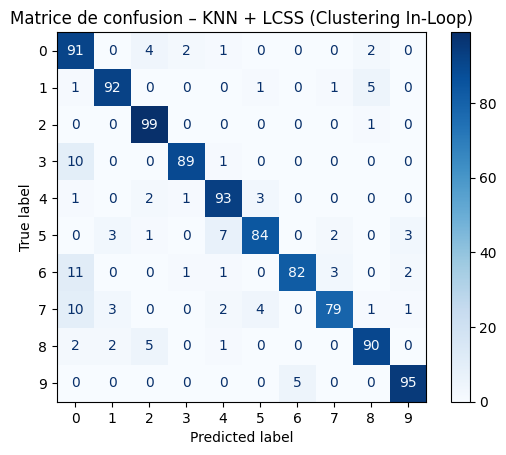

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d




DOMAIN_FOLDER = r"\\student.fucam.ac.be\users$\isadiki\Downloads\Domain2base\DOMAIN2_CSVcorrigé"

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:

                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue


                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])


                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)


                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df = pd.concat([df, file_df], ignore_index=True)

            except FileNotFoundError:
                continue
            except Exception:
                continue


for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Nombre total d'observations chargées : {len(df)}")



def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:

        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation en cours...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling en cours...")
df100 = resample_gesture(df)



def cluster_and_symbolize(train_df, test_df, k_clusters=20):

    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)

        symbols = [chr(ord('A') + (c % 26)) for c in clusters]

        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append("".join(group['symbol'].tolist()))
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)



def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):

    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = lcs_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]



def testmodel(df_input, loop_range=10, k_knn=3, k_clusters=20):
    total_true, total_pred = [], []

    for i in range(1, loop_range + 1):

        train_df = df_input[df_input["subject"] != i]
        test_df = df_input[df_input["subject"] == i]

        if test_df.empty:
            continue

        print(f"\n--- TEST SUJET SORTI : {i} ---")


        train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

        y_true, y_pred = [], []
        for gesture, sequences in test_dict.items():
            for seq in sequences:
                pred = knn_lcs_predict(seq, train_dict, k=k_knn)
                y_true.append(gesture)
                y_pred.append(pred)

        acc = accuracy_score(y_true, y_pred)
        print(f"Précision sujet {i} : {acc:.2%}")
        total_true.extend(y_true)
        total_pred.extend(y_pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE KNN-LCSS : {final_acc:.2%} ===")


    cm = confusion_matrix(total_true, total_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title("Matrice de confusion – KNN + LCSS (Clustering In-Loop)")
    plt.show()


testmodel(df100)

#installe matplotlib

In [ ]:
import sys
!"{sys.executable}" -m pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


#dtw

--- Début du Chargement ---
✅ Données chargées : 79866 lignes.


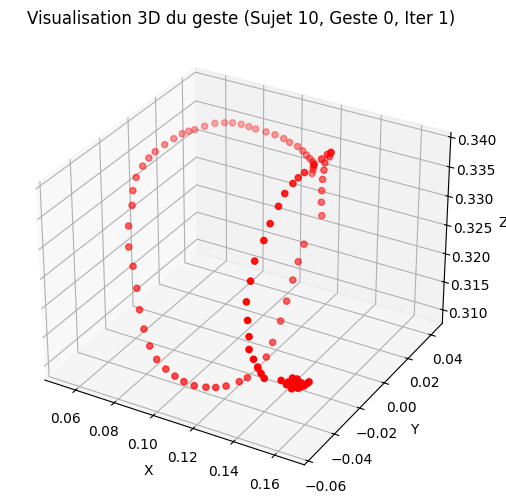


--- Durée moyenne des gestes (s) ---
gesture
0    3980.0
1    3567.2
2    2570.5
3    4037.7
4    3087.1
5    5395.7
6    4499.0
7    4250.9
8    2463.7
9    3477.0
Name: duration, dtype: float64


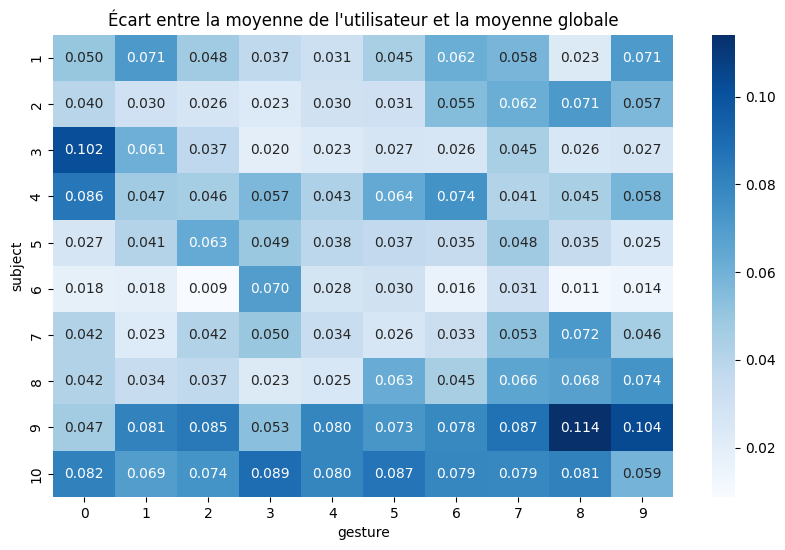

Standardisation...


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_18484\2285233954.py:112: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling...

--- Test Split OUT : 1 ---
Précision split 1 : 100.00%

--- Test Split OUT : 2 ---
Précision split 2 : 97.00%

--- Test Split OUT : 3 ---
Précision split 3 : 94.00%

--- Test Split OUT : 4 ---
Précision split 4 : 100.00%

--- Test Split OUT : 5 ---
Précision split 5 : 97.00%

--- Test Split OUT : 6 ---
Précision split 6 : 97.00%

--- Test Split OUT : 7 ---
Précision split 7 : 98.00%

--- Test Split OUT : 8 ---
Précision split 8 : 96.00%

--- Test Split OUT : 9 ---
Précision split 9 : 98.00%

--- Test Split OUT : 10 ---
Précision split 10 : 98.00%

✅ Précision GLOBALE : 97.50%


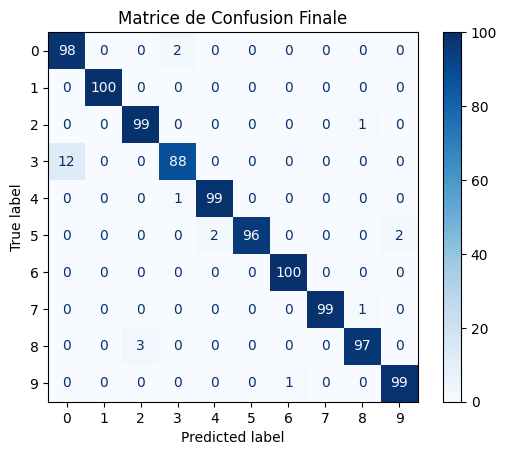

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import interp1d
import seaborn as sns



DOMAIN_FOLDER =r"\\student.fucam.ac.be\users$\isadiki\Downloads\Domain2base\DOMAIN2_CSVcorrigé"

df_list = []

print("--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:

                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue


                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])


                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)


                file_df['gesture'] = int(number)
                file_df['subject'] = int(subject)
                file_df['iter'] = int(iteration)

                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("❌ Aucun fichier chargé. Vérifiez le chemin : " + DOMAIN_FOLDER)

df = pd.concat(df_list, ignore_index=True)
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f" Données chargées : {len(df)} lignes.")



subdf = df.loc[(df['gesture'] == 0) & (df['subject'] == 10) & (df['iter'] == 1)]

if not subdf.empty:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(subdf['x'], subdf['y'], subdf['z'], c='red', s=20)
    ax.set_title("Visualisation 3D du geste (Sujet 10, Geste 0, Iter 1)")
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    plt.show()




durations = df.groupby(['gesture', 'iter'])['t'].agg(lambda x: x.max() - x.min()).reset_index(name='duration')
mean_durations = durations.groupby('gesture')['duration'].mean()
print("\n--- Durée moyenne des gestes (s) ---")
print(mean_durations)


mean_coords_user = df.groupby(['subject', 'gesture'])[['x', 'y', 'z']].mean().reset_index()
mean_coords_global = df.groupby('gesture')[['x', 'y', 'z']].mean().reset_index().rename(
    columns={'x':'x_global', 'y':'y_global', 'z':'z_global'})

merged = pd.merge(mean_coords_user, mean_coords_global, on='gesture')
merged['dist_to_global'] = np.sqrt((merged['x']-merged['x_global'])**2 +
                                   (merged['y']-merged['y_global'])**2 +
                                   (merged['z']-merged['z_global'])**2)

pivot = merged.pivot(index='subject', columns='gesture', values='dist_to_global')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap='Blues')
plt.title("Écart entre la moyenne de l'utilisateur et la moyenne globale")
plt.show()



def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)



def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]



def dict_creation_userout(df, subj_out):
    test_df = df[df["subject"] == subj_out]
    train_df = df[df["subject"] != subj_out]

    dict_train = defaultdict(list)
    dict_test = defaultdict(list)

    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())
    for (g, s, it), group in test_df.groupby(["gesture", "subject", "iter"]):
        dict_test[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())
    return dict_train, dict_test

def testmodel(DictCreationFunc, df, loop_range=10, k=3):
    total_true, total_pred = [], []
    for i in range(1, loop_range + 1):
        print(f"\n--- Test Split OUT : {i} ---")
        coord_train, coord_test = DictCreationFunc(df, i)
        y_true, y_pred = [], []
        for gesture, sequences in coord_test.items():
            for seq in sequences:
                pred = knn_dtw_predict(seq, coord_train, k=k)
                y_true.append(gesture)
                y_pred.append(pred)

        acc = accuracy_score(y_true, y_pred)
        total_true.extend(y_true); total_pred.extend(y_pred)
        print(f"Précision split {i} : {acc:.2%}")

    print(f"\nPrécision GLOBALE : {accuracy_score(total_true, total_pred):.2%}")
    cm = confusion_matrix(total_true, total_pred)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues")
    plt.title("Matrice de Confusion Finale")
    plt.show()


testmodel(dict_creation_userout, df100, loop_range=10, k=3)

In [ ]:
import os

# Ce script va chercher où se cachent tes fichiers .csv
for root, dirs, files in os.walk("/content/temp_data"):
    csv_files = [f for f in files if f.endswith('.csv')]
    if len(csv_files) > 0:
        print(f"✅ TROUVÉ ! Tes fichiers sont ici : {root}")
        print(f"Exemple de fichier : {csv_files[0]}")
        # On met à jour le chemin automatiquement
        DOMAIN_FOLDER = root
        break

✅ TROUVÉ ! Tes fichiers sont ici : /content/temp_data/DOMAIN2_CSV
Exemple de fichier : Subject6-1-8.csv


# lstm 64 32 32 test 5 train 4


In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN2_CSV"):
    !unzip -q /content/DOMAIN2_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSV"
DOMAIN_ID = 2
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(64, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(64),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 ---


/tmp/ipykernel_415/3547428122.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 145ms/step - accuracy: 0.2068 - loss: 2.2594 - val_accuracy: 0.0000e+00 - val_loss: 2.6716
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.2809 - loss: 2.1132 - val_accuracy: 0.0000e+00 - val_loss: 2.9940
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 0.3951 - loss: 1.8706 - val_accuracy: 0.0000e+00 - val_loss: 3.5799
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 174ms/step - accuracy: 0.4321 - loss: 1.5766 - val_accuracy: 0.0000e+00 - val_loss: 3.9222
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - accuracy: 0.5710 - loss: 1.3223 - val_accuracy: 0.0000e+00 - val_loss: 3.7979
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - accuracy: 0.6759 - loss: 1.0718 - val_accuracy: 0.0000e+00 - val_loss: 4.0497
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.7469 - loss: 0.8459 - val_accuracy: 0.0000e+00 - val_loss: 4.1569
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.8302 - loss: 0.6693 - val

# lstm 64 32 32 train 5V test 4


In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN2_CSV"):
    !unzip -q /content/DOMAIN2_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSV"
DOMAIN_ID = 2
TRAIN_SUBJECTS = [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(64, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(64),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 ---


/tmp/ipykernel_415/3592229362.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 138ms/step - accuracy: 0.1753 - loss: 2.2155 - val_accuracy: 0.0000e+00 - val_loss: 2.7392
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.2914 - loss: 1.9707 - val_accuracy: 0.0000e+00 - val_loss: 3.3571
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.6025 - loss: 1.5267 - val_accuracy: 0.0000e+00 - val_loss: 4.1821
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.7457 - loss: 0.9646 - val_accuracy: 0.0000e+00 - val_loss: 4.6085
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 173ms/step - accuracy: 0.8148 - loss: 0.6123 - val_accuracy: 0.0000e+00 - val_loss: 4.2639
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.8642 - loss: 0.4163 - val_accuracy: 0.0000e+00 - val_loss: 4.7597
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.9037 - loss: 0.3053 - val_accuracy: 0.0000e+00 - val_loss: 4.4874
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.9210 - loss: 0.2703 - val

# lstm 128 32 32 traéin 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN2_CSV"):
    !unzip -q /content/DOMAIN2_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSV"
DOMAIN_ID = 2
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(128, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(128),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 ---


/tmp/ipykernel_415/775837281.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 301ms/step - accuracy: 0.2284 - loss: 2.1352 - val_accuracy: 0.0000e+00 - val_loss: 2.7475
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 297ms/step - accuracy: 0.4043 - loss: 1.7821 - val_accuracy: 0.0000e+00 - val_loss: 3.0973
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 347ms/step - accuracy: 0.5401 - loss: 1.4022 - val_accuracy: 0.0000e+00 - val_loss: 3.8395
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 294ms/step - accuracy: 0.7099 - loss: 1.0369 - val_accuracy: 0.0000e+00 - val_loss: 5.3545
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 257ms/step - accuracy: 0.6914 - loss: 0.8333 - val_accuracy: 0.0000e+00 - val_loss: 5.5179
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 258ms/step - accuracy: 0.8148 - loss: 0.6030 - val_accuracy: 0.0000e+00 - val_loss: 5.0638
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 307ms/step - accuracy: 0.8364 - loss: 0.5312 - val_accuracy: 0.0000e+00 - val_loss: 5.4457
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 330ms/step - accuracy: 0.8951 - loss: 0.3776 -

# lstm 128 32 32 train 5 tets 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN2_CSV"):
    !unzip -q /content/DOMAIN2_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSV"
DOMAIN_ID = 2
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(128, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(128),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 ---


/tmp/ipykernel_415/3731310584.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 473ms/step - accuracy: 0.2444 - loss: 2.1520 - val_accuracy: 0.0000e+00 - val_loss: 3.2729
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 277ms/step - accuracy: 0.5852 - loss: 1.4437 - val_accuracy: 0.0000e+00 - val_loss: 4.3261
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 298ms/step - accuracy: 0.8667 - loss: 0.6313 - val_accuracy: 0.0000e+00 - val_loss: 4.3941
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 273ms/step - accuracy: 0.9185 - loss: 0.3851 - val_accuracy: 0.0000e+00 - val_loss: 4.2838
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 279ms/step - accuracy: 0.9556 - loss: 0.2033 - val_accuracy: 0.0000e+00 - val_loss: 4.1216
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 372ms/step - accuracy: 0.9457 - loss: 0.1971 - val_accuracy: 0.0000e+00 - val_loss: 4.8055
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 269ms/step - accuracy: 0.9383 - loss: 0.1791 - val_accuracy: 0.0222 - val_loss: 3.1656
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 270ms/step - accuracy: 0.9778 - loss: 0.0960 - va

# lstm 256 32 32 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN2_CSV"):
    !unzip -q /content/DOMAIN2_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSV"
DOMAIN_ID = 2
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 ---


/tmp/ipykernel_415/1119343803.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 936ms/step - accuracy: 0.2901 - loss: 1.9951 - val_accuracy: 0.0000e+00 - val_loss: 3.5803
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 831ms/step - accuracy: 0.4784 - loss: 1.4601 - val_accuracy: 0.0000e+00 - val_loss: 4.1073
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 751ms/step - accuracy: 0.7562 - loss: 0.8453 - val_accuracy: 0.0000e+00 - val_loss: 5.4073
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 882ms/step - accuracy: 0.7623 - loss: 0.6504 - val_accuracy: 0.0000e+00 - val_loss: 5.4413
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 893ms/step - accuracy: 0.8488 - loss: 0.5230 - val_accuracy: 0.0000e+00 - val_loss: 5.1965
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 752ms/step - accuracy: 0.8858 - loss: 0.3627 - val_accuracy: 0.0000e+00 - val_loss: 5.5889
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 888ms/step - accuracy: 0.9136 - loss: 0.3193 - val_accuracy: 0.0000e+00 - val_loss: 4.3829
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 891ms/step - accuracy: 0.9167 - loss: 0.2

# lstm 256 32 32 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN2_CSV"):
    !unzip -q /content/DOMAIN2_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSV"
DOMAIN_ID = 2
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 ---


/tmp/ipykernel_415/3506793184.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 865ms/step - accuracy: 0.4395 - loss: 1.8378 - val_accuracy: 0.0000e+00 - val_loss: 4.0772
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 767ms/step - accuracy: 0.7926 - loss: 0.6778 - val_accuracy: 0.0000e+00 - val_loss: 4.0729
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 877ms/step - accuracy: 0.8938 - loss: 0.3246 - val_accuracy: 0.0000e+00 - val_loss: 3.3967
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 879ms/step - accuracy: 0.8889 - loss: 0.3213 - val_accuracy: 0.0000e+00 - val_loss: 2.3733
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 775ms/step - accuracy: 0.9383 - loss: 0.1938 - val_accuracy: 0.0000e+00 - val_loss: 2.5883
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 802ms/step - accuracy: 0.9704 - loss: 0.1108 - val_accuracy: 0.3111 - val_loss: 2.1658
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 864ms/step - accuracy: 0.9457 - loss: 0.1508 - val_accuracy: 0.0889 - val_loss: 2.6592
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 886ms/step - accuracy: 0.9235 - loss: 0.2459 -

# lstm 256 dense 64 32 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN2_CSV"):
    !unzip -q /content/DOMAIN2_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSV"
DOMAIN_ID = 2
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 ---


/tmp/ipykernel_415/2548489233.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.2562 - loss: 1.9979 - val_accuracy: 0.0000e+00 - val_loss: 2.9513
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.6049 - loss: 1.1750 - val_accuracy: 0.0000e+00 - val_loss: 3.5221
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.7284 - loss: 0.7856 - val_accuracy: 0.0000e+00 - val_loss: 2.9401
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.7593 - loss: 0.6631 - val_accuracy: 0.0000e+00 - val_loss: 4.3399
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.8395 - loss: 0.4706 - val_accuracy: 0.0000e+00 - val_loss: 3.7769
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9228 - loss: 0.2638 - val_accuracy: 0.0000e+00 - val_loss: 3.6226
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 894ms/step - accuracy: 0.6821 - loss: 1.2203 - val_accuracy: 0.0000e+00 - val_loss: 2.6173
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 899ms/step - accuracy: 0.7994 - loss: 0.5667 - val_accur

# lstm 256 dense 64 32 trin 5 test *4*

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN2_CSV"):
    !unzip -q /content/DOMAIN2_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSV"
DOMAIN_ID = 2
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 ---


/tmp/ipykernel_415/1441021667.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 923ms/step - accuracy: 0.3580 - loss: 1.8688 - val_accuracy: 0.0000e+00 - val_loss: 5.8391
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 902ms/step - accuracy: 0.7333 - loss: 0.7912 - val_accuracy: 0.0000e+00 - val_loss: 4.5649
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 780ms/step - accuracy: 0.8889 - loss: 0.3687 - val_accuracy: 0.0000e+00 - val_loss: 4.6195
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 853ms/step - accuracy: 0.9407 - loss: 0.1665 - val_accuracy: 0.0444 - val_loss: 4.0276
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 930ms/step - accuracy: 0.9531 - loss: 0.1509 - val_accuracy: 0.0000e+00 - val_loss: 4.8623
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 896ms/step - accuracy: 0.9531 - loss: 0.1753 - val_accuracy: 0.4667 - val_loss: 2.1853
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 877ms/step - accuracy: 0.9556 - loss: 0.1256 - val_accuracy: 0.1111 - val_loss: 4.5791
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 790ms/step - accuracy: 0.9556 - loss: 0.1482 - val

# lstm 256 dense 16 32 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_smatrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN2_CSV"):
    !unzip -q /content/DOMAIN2_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSV"
DOMAIN_ID = 2
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dense(16, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 ---


/tmp/ipykernel_415/4041218132.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.2377 - loss: 2.0361 - val_accuracy: 0.0000e+00 - val_loss: 4.1202
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 17s 737ms/step - accuracy: 0.5062 - loss: 1.4153 - val_accuracy: 0.0000e+00 - val_loss: 5.5806
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 878ms/step - accuracy: 0.5340 - loss: 1.2771 - val_accuracy: 0.0000e+00 - val_loss: 6.1432
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 873ms/step - accuracy: 0.6883 - loss: 1.0012 - val_accuracy: 0.0000e+00 - val_loss: 6.6470
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 734ms/step - accuracy: 0.7438 - loss: 0.8872 - val_accuracy: 0.0000e+00 - val_loss: 8.2991
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 845ms/step - accuracy: 0.7469 - loss: 0.7164 - val_accuracy: 0.0000e+00 - val_loss: 7.2837
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 917ms/step - accuracy: 0.8117 - loss: 0.5830 - val_accuracy: 0.0000e+00 - val_loss: 8.2930
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 805ms/step - accuracy: 0.8827 - 

# lstm 256 densde 16 32 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN2_CSV"):
    !unzip -q /content/DOMAIN2_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSV"
DOMAIN_ID = 2
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dense(16, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 ---


/tmp/ipykernel_415/4054484375.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 947ms/step - accuracy: 0.3383 - loss: 1.9043 - val_accuracy: 0.0000e+00 - val_loss: 3.9508
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 899ms/step - accuracy: 0.7457 - loss: 0.8227 - val_accuracy: 0.0000e+00 - val_loss: 5.7983
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 796ms/step - accuracy: 0.9160 - loss: 0.3740 - val_accuracy: 0.0000e+00 - val_loss: 4.9072
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 869ms/step - accuracy: 0.9284 - loss: 0.2808 - val_accuracy: 0.0000e+00 - val_loss: 6.7744
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 897ms/step - accuracy: 0.8963 - loss: 0.3492 - val_accuracy: 0.0000e+00 - val_loss: 3.6507
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 885ms/step - accuracy: 0.9506 - loss: 0.2237 - val_accuracy: 0.0000e+00 - val_loss: 4.3365
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 809ms/step - accuracy: 0.9580 - loss: 0.1740 - val_accuracy: 0.1111 - val_loss: 3.0567
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 909ms/step - accuracy: 0.9753 -

# lstm 256 32 batch size 64 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN2_CSV"):
    !unzip -q /content/DOMAIN2_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSV"
DOMAIN_ID = 2
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 ---


/tmp/ipykernel_415/2298156250.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.2130 - loss: 2.1421 - val_accuracy: 0.0000e+00 - val_loss: 3.9197
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 997ms/step - accuracy: 0.4537 - loss: 1.6331 - val_accuracy: 0.0000e+00 - val_loss: 4.8213
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.5741 - loss: 1.1720 - val_accuracy: 0.0000e+00 - val_loss: 7.0682
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.6296 - loss: 1.0012 - val_accuracy: 0.0000e+00 - val_loss: 6.2847
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.6790 - loss: 0.8268 - val_accuracy: 0.0000e+00 - val_loss: 5.3604
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.7377 - loss: 0.7122 - val_accuracy: 0.0000e+00 - val_loss: 5.2279
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.7531 - loss: 0.6186 - val_accuracy: 0.0000e+00 - val_loss: 4.8276
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.7901 - loss: 0.5830 - val_accuracy: 0.0000e+00 - val_

# lstm 256 32 64 tain 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN2_CSV"):
    !unzip -q /content/DOMAIN2_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSV"
DOMAIN_ID = 2
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 ---


/tmp/ipykernel_415/491001597.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.2321 - loss: 2.0839 - val_accuracy: 0.0000e+00 - val_loss: 4.0696
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.6000 - loss: 1.2470 - val_accuracy: 0.0000e+00 - val_loss: 5.8421
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7630 - loss: 0.6939 - val_accuracy: 0.0000e+00 - val_loss: 5.6979
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.8420 - loss: 0.4931 - val_accuracy: 0.0000e+00 - val_loss: 6.1204
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9136 - loss: 0.2709 - val_accuracy: 0.0000e+00 - val_loss: 4.0144
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9235 - loss: 0.2813 - val_accuracy: 0.0000e+00 - val_loss: 3.9176
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9481 - loss: 0.1688 - val_accuracy: 0.0000e+00 - val_loss: 3.8636
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9580 - loss: 0.1341 - val_accuracy: 0.0889 - val_loss: 3.1

# lstm 256 32 batch size 16 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN2_CSV"):
    !unzip -q /content/DOMAIN2_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSV"
DOMAIN_ID = 2
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 ---


/tmp/ipykernel_415/1878308852.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 17s 640ms/step - accuracy: 0.3302 - loss: 1.7874 - val_accuracy: 0.0000e+00 - val_loss: 5.4703
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 608ms/step - accuracy: 0.6636 - loss: 1.0112 - val_accuracy: 0.0000e+00 - val_loss: 6.7690
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 606ms/step - accuracy: 0.7716 - loss: 0.6738 - val_accuracy: 0.0000e+00 - val_loss: 4.8033
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 602ms/step - accuracy: 0.8673 - loss: 0.4063 - val_accuracy: 0.0000e+00 - val_loss: 4.9810
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 579ms/step - accuracy: 0.8488 - loss: 0.5366 - val_accuracy: 0.0000e+00 - val_loss: 4.3776
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 21s 607ms/step - accuracy: 0.7870 - loss: 0.7290 - val_accuracy: 0.0000e+00 - val_loss: 3.8153
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 615ms/step - accuracy: 0.9290 - loss: 0.2846 - val_accuracy: 0.0000e+00 - val_loss: 3.7231
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 607ms/step - accuracy: 0.9383 - loss: 

# lstm 256 32 16 trian 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN2_CSV"):
    !unzip -q /content/DOMAIN2_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSV"
DOMAIN_ID = 2
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 ---


/tmp/ipykernel_415/3265003976.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 19s 615ms/step - accuracy: 0.4469 - loss: 1.6106 - val_accuracy: 0.0000e+00 - val_loss: 3.3719
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 17s 625ms/step - accuracy: 0.8593 - loss: 0.4908 - val_accuracy: 0.0000e+00 - val_loss: 3.6643
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 591ms/step - accuracy: 0.9086 - loss: 0.3245 - val_accuracy: 0.0000e+00 - val_loss: 3.5990
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 593ms/step - accuracy: 0.9185 - loss: 0.2613 - val_accuracy: 0.0000e+00 - val_loss: 3.1403
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 586ms/step - accuracy: 0.9358 - loss: 0.2019 - val_accuracy: 0.0222 - val_loss: 3.4733
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 22s 620ms/step - accuracy: 0.9432 - loss: 0.1737 - val_accuracy: 0.3556 - val_loss: 1.6153
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 593ms/step - accuracy: 0.9185 - loss: 0.2340 - val_accuracy: 0.1111 - val_loss: 1.8461
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 16s 615ms/step - accuracy: 0.9852 - loss: 0.0845 - val

# transformer

# tranhsfo 64 64 32 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN2_CSV"):
    !unzip -q /content/DOMAIN2_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSV"
DOMAIN_ID = 2

# Sujets demandés
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)
print(f"Nombre total d'observations chargées : {len(df)}")

# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 64, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)



--- 1. Début du Chargement du Domaine 2 (Transformer) ---
Nombre total d'observations chargées : 72077


/tmp/ipykernel_415/1521607308.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.1019 - loss: 2.3549 - val_accuracy: 0.0000e+00 - val_loss: 3.2132
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.1142 - loss: 2.2392 - val_accuracy: 0.0000e+00 - val_loss: 3.4486
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.1327 - loss: 2.2310 - val_accuracy: 0.0000e+00 - val_loss: 4.0374
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1451 - loss: 2.1972 - val_accuracy: 0.0000e+00 - val_loss: 3.3411
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1574 - loss: 2.1582 - val_accuracy: 0.0000e+00 - val_loss: 3.6126
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.4321 - loss: 1.7147 - val_accuracy: 0.0000e+00 - val_loss: 4.7113
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.7407 - loss: 0.8483 - val_accuracy: 0.0000e+00 - val_loss: 4.8955
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - 

# tranfo 64 64 32 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN2_CSV"):
    !unzip -q /content/DOMAIN2_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSV"
DOMAIN_ID = 2

# Sujets demandés
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)
print(f"Nombre total d'observations chargées : {len(df)}")

# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 64, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 (Transformer) ---
Nombre total d'observations chargées : 72077


/tmp/ipykernel_415/3414571980.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.1210 - loss: 2.3818 - val_accuracy: 0.0000e+00 - val_loss: 3.7280
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.1457 - loss: 2.1949 - val_accuracy: 0.0000e+00 - val_loss: 3.6017
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.2593 - loss: 1.8862 - val_accuracy: 0.0000e+00 - val_loss: 4.2615
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.7432 - loss: 0.8278 - val_accuracy: 0.0000e+00 - val_loss: 5.3163
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9185 - loss: 0.3074 - val_accuracy: 0.0000e+00 - val_loss: 3.8666
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.9630 - loss: 0.1584 - val_accuracy: 0.4889 - val_loss: 2.0742
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9852 - loss: 0.0793 - val_accuracy: 0.5778 - val_loss: 1.9157
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy

# transo 128 64 32 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN2_CSV"):
    !unzip -q /content/DOMAIN2_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSV"
DOMAIN_ID = 2

# Sujets demandés
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)
print(f"Nombre total d'observations chargées : {len(df)}")

# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 128, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 (Transformer) ---
Nombre total d'observations chargées : 72077


/tmp/ipykernel_415/3837281654.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1111 - loss: 2.4145 - val_accuracy: 0.0000e+00 - val_loss: 4.1606
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.1080 - loss: 2.2348 - val_accuracy: 0.0000e+00 - val_loss: 3.8783
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.1111 - loss: 2.2049 - val_accuracy: 0.0000e+00 - val_loss: 4.2049
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.1080 - loss: 2.2343 - val_accuracy: 0.0000e+00 - val_loss: 3.6918
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1358 - loss: 2.1759 - val_accuracy: 0.0000e+00 - val_loss: 3.9725
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.1944 - loss: 2.0325 - val_accuracy: 0.0000e+00 - val_loss: 4.7664
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.5340 - loss: 1.3620 - val_accuracy: 0.0000e+00 - val_loss: 4.8821
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - 

# tranqgfo 128 64 32 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN2_CSV"):
    !unzip -q /content/DOMAIN2_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSV"
DOMAIN_ID = 2

# Sujets demandés
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)
print(f"Nombre total d'observations chargées : {len(df)}")

# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 128, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 (Transformer) ---
Nombre total d'observations chargées : 72077


/tmp/ipykernel_415/1208839577.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.1457 - loss: 2.3192 - val_accuracy: 0.0000e+00 - val_loss: 2.9732
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.1383 - loss: 2.2477 - val_accuracy: 0.0000e+00 - val_loss: 3.4291
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.1358 - loss: 2.2193 - val_accuracy: 0.0000e+00 - val_loss: 3.3000
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.3481 - loss: 1.7253 - val_accuracy: 0.0000e+00 - val_loss: 5.2192
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.7827 - loss: 0.7532 - val_accuracy: 0.0889 - val_loss: 3.6690
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.9778 - loss: 0.1703 - val_accuracy: 0.2222 - val_loss: 3.7786
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.9877 - loss: 0.0639 - val_accuracy: 0.0889 - val_loss: 4.6546
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.

# traqnfo 256 64 32 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN2_CSV"):
    !unzip -q /content/DOMAIN2_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSV"
DOMAIN_ID = 2

# Sujets demandés
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)
print(f"Nombre total d'observations chargées : {len(df)}")

# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 (Transformer) ---
Nombre total d'observations chargées : 72077


/tmp/ipykernel_415/3482554458.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.1019 - loss: 2.3340 - val_accuracy: 0.0000e+00 - val_loss: 3.2358
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.1204 - loss: 2.2315 - val_accuracy: 0.0000e+00 - val_loss: 3.4481
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.1173 - loss: 2.2130 - val_accuracy: 0.0000e+00 - val_loss: 3.0754
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.1265 - loss: 2.1995 - val_accuracy: 0.0000e+00 - val_loss: 3.7027
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.1111 - loss: 2.2019 - val_accuracy: 0.0000e+00 - val_loss: 3.5433
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.1975 - loss: 2.1144 - val_accuracy: 0.0000e+00 - val_loss: 4.5727
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.2654 - loss: 1.8422 - val_accuracy: 0.0000e+00 - val_loss: 4.8040
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - 

# trasnfo 256 64 32 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN2_CSV"):
    !unzip -q /content/DOMAIN2_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSV"
DOMAIN_ID = 2

# Sujets demandés
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)
print(f"Nombre total d'observations chargées : {len(df)}")

# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 (Transformer) ---
Nombre total d'observations chargées : 72077


/tmp/ipykernel_415/2064435102.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.1407 - loss: 2.4308 - val_accuracy: 0.0000e+00 - val_loss: 4.0907
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.1556 - loss: 2.2081 - val_accuracy: 0.0000e+00 - val_loss: 4.1893
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.1506 - loss: 2.1372 - val_accuracy: 0.0000e+00 - val_loss: 3.4722
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.5432 - loss: 1.4243 - val_accuracy: 0.0000e+00 - val_loss: 3.6337
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.9407 - loss: 0.3304 - val_accuracy: 0.0000e+00 - val_loss: 4.9876
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.9679 - loss: 0.1284 - val_accuracy: 0.4444 - val_loss: 2.5984
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.9852 - loss: 0.0789 - val_accuracy: 0.6000 - val_loss: 1.6182
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy

# transofd 64 128 32 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN2_CSV"):
    !unzip -q /content/DOMAIN2_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSV"
DOMAIN_ID = 2

# Sujets demandés
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)
print(f"Nombre total d'observations chargées : {len(df)}")

# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 64, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 (Transformer) ---
Nombre total d'observations chargées : 72077


/tmp/ipykernel_415/431561522.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.1049 - loss: 2.4087 - val_accuracy: 0.0000e+00 - val_loss: 4.2819
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.1111 - loss: 2.2527 - val_accuracy: 0.0000e+00 - val_loss: 4.1356
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.1574 - loss: 2.1447 - val_accuracy: 0.0000e+00 - val_loss: 4.5139
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.3117 - loss: 1.7735 - val_accuracy: 0.0000e+00 - val_loss: 4.9064
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.5648 - loss: 1.1324 - val_accuracy: 0.0000e+00 - val_loss: 3.7891
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.8302 - loss: 0.5363 - val_accuracy: 0.0556 - val_loss: 3.4605
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.8735 - loss: 0.3265 - val_accuracy: 0.0000e+00 - val_loss: 4.5447
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accu

# trnsof 64 128 32 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN2_CSV"):
    !unzip -q /content/DOMAIN2_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSV"
DOMAIN_ID = 2

# Sujets demandés
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)
print(f"Nombre total d'observations chargées : {len(df)}")

# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 64, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 (Transformer) ---
Nombre total d'observations chargées : 72077


/tmp/ipykernel_415/1243580802.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.1309 - loss: 2.3152 - val_accuracy: 0.0000e+00 - val_loss: 4.1058
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.1235 - loss: 2.1952 - val_accuracy: 0.0000e+00 - val_loss: 4.7802
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.2914 - loss: 1.9302 - val_accuracy: 0.0000e+00 - val_loss: 4.3433
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.7877 - loss: 0.6669 - val_accuracy: 0.0444 - val_loss: 3.9812
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9605 - loss: 0.1615 - val_accuracy: 0.3778 - val_loss: 2.6581
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9852 - loss: 0.0650 - val_accuracy: 0.5111 - val_loss: 2.2113
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9852 - loss: 0.0384 - val_accuracy: 0.6667 - val_loss: 2.2261
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.9951

# transfo 64 64 32 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN2_CSV"):
    !unzip -q /content/DOMAIN2_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSV"
DOMAIN_ID = 2

# Sujets demandés
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)
print(f"Nombre total d'observations chargées : {len(df)}")

# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 64, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 (Transformer) ---
Nombre total d'observations chargées : 72077


/tmp/ipykernel_415/2236919269.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.1019 - loss: 2.4696 - val_accuracy: 0.0000e+00 - val_loss: 2.7346
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.1481 - loss: 2.2347 - val_accuracy: 0.0000e+00 - val_loss: 3.3134
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.1512 - loss: 2.2580 - val_accuracy: 0.0000e+00 - val_loss: 3.5769
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.2315 - loss: 2.0300 - val_accuracy: 0.0000e+00 - val_loss: 3.9456
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.4383 - loss: 1.4314 - val_accuracy: 0.0000e+00 - val_loss: 5.4078
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.5710 - loss: 1.0250 - val_accuracy: 0.0000e+00 - val_loss: 4.5891
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.7963 - loss: 0.5852 - val_accuracy: 0.0000e+00 - val_loss: 3.9523
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - 

# transfo 64 64 32 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN2_CSV"):
    !unzip -q /content/DOMAIN2_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSV"
DOMAIN_ID = 2

# Sujets demandés
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)
print(f"Nombre total d'observations chargées : {len(df)}")

# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 64, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 (Transformer) ---
Nombre total d'observations chargées : 72077


/tmp/ipykernel_415/3414571980.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.1259 - loss: 2.3301 - val_accuracy: 0.0000e+00 - val_loss: 3.0191
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.1136 - loss: 2.2210 - val_accuracy: 0.0000e+00 - val_loss: 3.1747
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.1457 - loss: 2.1936 - val_accuracy: 0.0000e+00 - val_loss: 3.3296
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.4346 - loss: 1.6032 - val_accuracy: 0.0000e+00 - val_loss: 4.7885
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.8593 - loss: 0.5367 - val_accuracy: 0.0000e+00 - val_loss: 3.6587
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.9580 - loss: 0.2300 - val_accuracy: 0.2222 - val_loss: 2.7045
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9852 - loss: 0.1115 - val_accuracy: 0.1111 - val_loss: 3.3426
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy

# transfo 64 64 bathc 64 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN2_CSV"):
    !unzip -q /content/DOMAIN2_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSV"
DOMAIN_ID = 2

# Sujets demandés
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)
print(f"Nombre total d'observations chargées : {len(df)}")

# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 64, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 (Transformer) ---
Nombre total d'observations chargées : 72077


/tmp/ipykernel_415/2119570442.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.1111 - loss: 2.3191 - val_accuracy: 0.0000e+00 - val_loss: 4.2765
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 28s 5s/step - accuracy: 0.1420 - loss: 2.3767 - val_accuracy: 0.0000e+00 - val_loss: 3.5343
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 28s 5s/step - accuracy: 0.1543 - loss: 2.2439 - val_accuracy: 0.0000e+00 - val_loss: 4.0135
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - accuracy: 0.0988 - loss: 2.2144 - val_accuracy: 0.0000e+00 - val_loss: 4.0263
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.1389 - loss: 2.1492 - val_accuracy: 0.0000e+00 - val_loss: 3.8441
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.2284 - loss: 2.0798 - val_accuracy: 0.0000e+00 - val_loss: 4.0756
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.3488 - loss: 1.7566 - val_accuracy: 0.0000e+00 - val_loss: 5.1193
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.4444

# transfp 64 64 64 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN2_CSV"):
    !unzip -q /content/DOMAIN2_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSV"
DOMAIN_ID = 2

# Sujets demandés
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)
print(f"Nombre total d'observations chargées : {len(df)}")

# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 64, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 (Transformer) ---
Nombre total d'observations chargées : 72077


/tmp/ipykernel_415/931329062.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 44s 4s/step - accuracy: 0.1210 - loss: 2.4118 - val_accuracy: 0.0000e+00 - val_loss: 3.3511
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 31s 4s/step - accuracy: 0.0864 - loss: 2.2299 - val_accuracy: 0.0000e+00 - val_loss: 3.2126
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 5s/step - accuracy: 0.0963 - loss: 2.2132 - val_accuracy: 0.0000e+00 - val_loss: 3.8003
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.1827 - loss: 2.1488 - val_accuracy: 0.0000e+00 - val_loss: 3.8602
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.2444 - loss: 1.9659 - val_accuracy: 0.0000e+00 - val_loss: 3.6071
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.5679 - loss: 1.3276 - val_accuracy: 0.0000e+00 - val_loss: 5.3625
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.8741 - loss: 0.5656 - val_accuracy: 0.0000e+00 - val_loss: 4.6942
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.9506

# transfo 64 64 16 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN2_CSV"):
    !unzip -q /content/DOMAIN2_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSV"
DOMAIN_ID = 2

# Sujets demandés
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)
print(f"Nombre total d'observations chargées : {len(df)}")

# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 64, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 (Transformer) ---
Nombre total d'observations chargées : 72077


/tmp/ipykernel_415/916984944.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 22s 656ms/step - accuracy: 0.1173 - loss: 2.3613 - val_accuracy: 0.0000e+00 - val_loss: 3.3842
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 609ms/step - accuracy: 0.1512 - loss: 2.2390 - val_accuracy: 0.0000e+00 - val_loss: 3.7131
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 573ms/step - accuracy: 0.2963 - loss: 1.8559 - val_accuracy: 0.0000e+00 - val_loss: 3.7081
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 532ms/step - accuracy: 0.5617 - loss: 1.1678 - val_accuracy: 0.0000e+00 - val_loss: 4.7100
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 578ms/step - accuracy: 0.7377 - loss: 0.6800 - val_accuracy: 0.0000e+00 - val_loss: 4.4661
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 614ms/step - accuracy: 0.8056 - loss: 0.5379 - val_accuracy: 0.0000e+00 - val_loss: 4.3649
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 602ms/step - accuracy: 0.9259 - loss: 0.2919 - val_accuracy: 0.0000e+00 - val_loss: 3.4575
Epoch 8/50
21/21 ━━━━━━━━━━━━━━

# transfo 64 64 16 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN2_CSV"):
    !unzip -q /content/DOMAIN2_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSV"
DOMAIN_ID = 2

# Sujets demandés
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)
print(f"Nombre total d'observations chargées : {len(df)}")

# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 64, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 (Transformer) ---
Nombre total d'observations chargées : 72077


/tmp/ipykernel_415/1423141737.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 27s 607ms/step - accuracy: 0.1481 - loss: 2.3041 - val_accuracy: 0.0000e+00 - val_loss: 3.2261
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 16s 619ms/step - accuracy: 0.2296 - loss: 2.0326 - val_accuracy: 0.0000e+00 - val_loss: 3.8939
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 587ms/step - accuracy: 0.7630 - loss: 0.6659 - val_accuracy: 0.0667 - val_loss: 2.6459
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 594ms/step - accuracy: 0.9037 - loss: 0.2833 - val_accuracy: 0.0000e+00 - val_loss: 4.9390
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 585ms/step - accuracy: 0.9605 - loss: 0.1550 - val_accuracy: 0.5556 - val_loss: 1.6672
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 17s 640ms/step - accuracy: 0.9605 - loss: 0.1409 - val_accuracy: 0.3111 - val_loss: 3.4543
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 19s 586ms/step - accuracy: 0.9630 - loss: 0.1424 - val_accuracy: 0.1333 - val_loss: 3.8880
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 589ms

# dtw knn 3 trin 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN2_CSV"):
    !unzip -q /content/DOMAIN2_CSV.zip -d /content/temp_data
    print(" Décompression terminée !")

# --- 2. CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSV"
DOMAIN_ID = 2

# Configuration demandée
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Sujet 3 exclu par omission

df_list = []
print(f"--- 1. Chargement : Train sur {TRAIN_SUBJECTS}, Test sur {TEST_SUBJECTS} ---")

for subject in (TRAIN_SUBJECTS + TEST_SUBJECTS):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

# --- 3. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling (100 points)...")
df100 = resample_gesture(df, target_len=100)

# --- 4. DTW LOGIC ---
def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

# --- 5. ÉVALUATION AVEC AFFICHAGE PAR SUJET ---
def run_evaluation_by_subject(df_prep, train_list, test_list, k=3):
    # Préparation du dictionnaire de train (global pour tous les tests)
    train_df = df_prep[df_prep["subject"].isin(train_list)]
    dict_train = defaultdict(list)
    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())

    all_true, all_pred = [], []

    print(f"\n--- Début des tests sur les sujets {test_list} ---")

    # Évaluation individuelle pour chaque sujet de test
    for subj_id in test_list:
        subj_df = df_prep[df_prep["subject"] == subj_id]
        y_true_subj, y_pred_subj = [], []

        # Groupement par geste/itération pour ce sujet précis
        for (g, it), group in subj_df.groupby(["gesture", "iter"]):
            seq = group[["x_std", "y_std", "z_std"]].values.tolist()
            pred = knn_dtw_predict(seq, dict_train, k=k)
            y_true_subj.append(g)
            y_pred_subj.append(pred)

        acc_subj = accuracy_score(y_true_subj, y_pred_subj)
        print(f"Résultat Sujet {subj_id} : {acc_subj:.2%}")

        all_true.extend(y_true_subj)
        all_pred.extend(y_pred_subj)

    # Résultat Final
    print("-" * 30)
    print(f" PRÉCISION GLOBALE : {accuracy_score(all_true, all_pred):.2%}")



# Lancement
run_evaluation_by_subject(df100, TRAIN_SUBJECTS, TEST_SUBJECTS, k=3)

--- 1. Chargement : Train sur [1, 2, 4, 5], Test sur [6, 7, 8, 9, 10] ---
Standardisation...


/tmp/ipykernel_11238/3012464243.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling (100 points)...

--- Début des tests sur les sujets [6, 7, 8, 9, 10] ---
Résultat Sujet 6 : 81.11%
Résultat Sujet 7 : 94.44%
Résultat Sujet 8 : 77.78%
Résultat Sujet 9 : 92.22%
Résultat Sujet 10 : 93.33%
------------------------------
 PRÉCISION GLOBALE : 87.78%


# dtw knn 3 train 5 tets 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN2_CSV"):
    !unzip -q /content/DOMAIN2_CSV.zip -d /content/temp_data
    print(" Décompression terminée !")

# --- 2. CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSV"
DOMAIN_ID = 2

# Configuration demandée
TRAIN_SUBJECTS = [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Sujet 3 exclu par omission

df_list = []
print(f"--- 1. Chargement : Train sur {TRAIN_SUBJECTS}, Test sur {TEST_SUBJECTS} ---")

for subject in (TRAIN_SUBJECTS + TEST_SUBJECTS):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

# --- 3. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling (100points)...")
df100= resample_gesture(df, target_len=100)

# --- 4. DTW LOGIC ---
def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

# --- 5. ÉVALUATION AVEC AFFICHAGE PAR SUJET ---
def run_evaluation_by_subject(df_prep, train_list, test_list, k=3):
    # Préparation du dictionnaire de train (global pour tous les tests)
    train_df = df_prep[df_prep["subject"].isin(train_list)]
    dict_train = defaultdict(list)
    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())

    all_true, all_pred = [], []

    print(f"\n--- Début des tests sur les sujets {test_list} ---")

    # Évaluation individuelle pour chaque sujet de test
    for subj_id in test_list:
        subj_df = df_prep[df_prep["subject"] == subj_id]
        y_true_subj, y_pred_subj = [], []

        # Groupement par geste/itération pour ce sujet précis
        for (g, it), group in subj_df.groupby(["gesture", "iter"]):
            seq = group[["x_std", "y_std", "z_std"]].values.tolist()
            pred = knn_dtw_predict(seq, dict_train, k=k)
            y_true_subj.append(g)
            y_pred_subj.append(pred)

        acc_subj = accuracy_score(y_true_subj, y_pred_subj)
        print(f"Résultat Sujet {subj_id} : {acc_subj:.2%}")

        all_true.extend(y_true_subj)
        all_pred.extend(y_pred_subj)

    # Résultat Final
    print("-" * 30)
    print(f" PRÉCISION GLOBALE : {accuracy_score(all_true, all_pred):.2%}")



# Lancement
run_evaluation_by_subject(df100, TRAIN_SUBJECTS, TEST_SUBJECTS, k=3)

--- 1. Chargement : Train sur [6, 7, 8, 9, 10], Test sur [1, 2, 4, 5] ---
Standardisation...


/tmp/ipykernel_11238/2304354132.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling (100points)...

--- Début des tests sur les sujets [1, 2, 4, 5] ---
Résultat Sujet 1 : 98.89%
Résultat Sujet 2 : 86.67%
Résultat Sujet 4 : 96.67%
Résultat Sujet 5 : 87.78%
------------------------------
 PRÉCISION GLOBALE : 92.50%


# dtw knn 5 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN2_CSV"):
    !unzip -q /content/DOMAIN2_CSV.zip -d /content/temp_data
    print(" Décompression terminée !")

# --- 2. CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSV"
DOMAIN_ID = 2

# Configuration demandée
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Sujet 3 exclu par omission

df_list = []
print(f"--- 1. Chargement : Train sur {TRAIN_SUBJECTS}, Test sur {TEST_SUBJECTS} ---")

for subject in (TRAIN_SUBJECTS + TEST_SUBJECTS):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

# --- 3. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling (100 points)...")
df100 = resample_gesture(df, target_len=100)

# --- 4. DTW LOGIC ---
def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=5):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

# --- 5. ÉVALUATION AVEC AFFICHAGE PAR SUJET ---
def run_evaluation_by_subject(df_prep, train_list, test_list, k=5):
    # Préparation du dictionnaire de train (global pour tous les tests)
    train_df = df_prep[df_prep["subject"].isin(train_list)]
    dict_train = defaultdict(list)
    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())

    all_true, all_pred = [], []

    print(f"\n--- Début des tests sur les sujets {test_list} ---")

    # Évaluation individuelle pour chaque sujet de test
    for subj_id in test_list:
        subj_df = df_prep[df_prep["subject"] == subj_id]
        y_true_subj, y_pred_subj = [], []

        # Groupement par geste/itération pour ce sujet précis
        for (g, it), group in subj_df.groupby(["gesture", "iter"]):
            seq = group[["x_std", "y_std", "z_std"]].values.tolist()
            pred = knn_dtw_predict(seq, dict_train, k=k)
            y_true_subj.append(g)
            y_pred_subj.append(pred)

        acc_subj = accuracy_score(y_true_subj, y_pred_subj)
        print(f"Résultat Sujet {subj_id} : {acc_subj:.2%}")

        all_true.extend(y_true_subj)
        all_pred.extend(y_pred_subj)

    # Résultat Final
    print("-" * 30)
    print(f" PRÉCISION GLOBALE : {accuracy_score(all_true, all_pred):.2%}")



# Lancement
run_evaluation_by_subject(df100, TRAIN_SUBJECTS, TEST_SUBJECTS, k=5)

--- 1. Chargement : Train sur [1, 2, 4, 5], Test sur [6, 7, 8, 9, 10] ---
Standardisation...


/tmp/ipykernel_11238/4116295946.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling (100 points)...

--- Début des tests sur les sujets [6, 7, 8, 9, 10] ---
Résultat Sujet 6 : 77.78%
Résultat Sujet 7 : 93.33%
Résultat Sujet 8 : 75.56%
Résultat Sujet 9 : 92.22%
Résultat Sujet 10 : 91.11%
------------------------------
 PRÉCISION GLOBALE : 86.00%


# dtw knn 5 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN2_CSV"):
    !unzip -q /content/DOMAIN2_CSV.zip -d /content/temp_data
    print(" Décompression terminée !")

# --- 2. CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSV"
DOMAIN_ID = 2

# Configuration demandée
TRAIN_SUBJECTS = [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Sujet 3 exclu par omission

df_list = []
print(f"--- 1. Chargement : Train sur {TRAIN_SUBJECTS}, Test sur {TEST_SUBJECTS} ---")

for subject in (TRAIN_SUBJECTS + TEST_SUBJECTS):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

# --- 3. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling (100points)...")
df100= resample_gesture(df, target_len=100)

# --- 4. DTW LOGIC ---
def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=5):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

# --- 5. ÉVALUATION AVEC AFFICHAGE PAR SUJET ---
def run_evaluation_by_subject(df_prep, train_list, test_list, k=5):
    # Préparation du dictionnaire de train (global pour tous les tests)
    train_df = df_prep[df_prep["subject"].isin(train_list)]
    dict_train = defaultdict(list)
    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())

    all_true, all_pred = [], []

    print(f"\n--- Début des tests sur les sujets {test_list} ---")

    # Évaluation individuelle pour chaque sujet de test
    for subj_id in test_list:
        subj_df = df_prep[df_prep["subject"] == subj_id]
        y_true_subj, y_pred_subj = [], []

        # Groupement par geste/itération pour ce sujet précis
        for (g, it), group in subj_df.groupby(["gesture", "iter"]):
            seq = group[["x_std", "y_std", "z_std"]].values.tolist()
            pred = knn_dtw_predict(seq, dict_train, k=k)
            y_true_subj.append(g)
            y_pred_subj.append(pred)

        acc_subj = accuracy_score(y_true_subj, y_pred_subj)
        print(f"Résultat Sujet {subj_id} : {acc_subj:.2%}")

        all_true.extend(y_true_subj)
        all_pred.extend(y_pred_subj)

    # Résultat Final
    print("-" * 30)
    print(f" PRÉCISION GLOBALE : {accuracy_score(all_true, all_pred):.2%}")



# Lancement
run_evaluation_by_subject(df100, TRAIN_SUBJECTS, TEST_SUBJECTS, k=5)

--- 1. Chargement : Train sur [6, 7, 8, 9, 10], Test sur [1, 2, 4, 5] ---
Standardisation...


/tmp/ipykernel_11238/1416780077.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling (100points)...

--- Début des tests sur les sujets [1, 2, 4, 5] ---
Résultat Sujet 1 : 100.00%
Résultat Sujet 2 : 90.00%
Résultat Sujet 4 : 96.67%
Résultat Sujet 5 : 91.11%
------------------------------
 PRÉCISION GLOBALE : 94.44%


# dtw knn 7 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN2_CSV"):
    !unzip -q /content/DOMAIN2_CSV.zip -d /content/temp_data
    print(" Décompression terminée !")

# --- 2. CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSV"
DOMAIN_ID = 2

# Configuration demandée
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Sujet 3 exclu par omission

df_list = []
print(f"--- 1. Chargement : Train sur {TRAIN_SUBJECTS}, Test sur {TEST_SUBJECTS} ---")

for subject in (TRAIN_SUBJECTS + TEST_SUBJECTS):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

# --- 3. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling (100 points)...")
df100 = resample_gesture(df, target_len=100)

# --- 4. DTW LOGIC ---
def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=7):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

# --- 5. ÉVALUATION AVEC AFFICHAGE PAR SUJET ---
def run_evaluation_by_subject(df_prep, train_list, test_list, k=7):
    # Préparation du dictionnaire de train (global pour tous les tests)
    train_df = df_prep[df_prep["subject"].isin(train_list)]
    dict_train = defaultdict(list)
    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())

    all_true, all_pred = [], []

    print(f"\n--- Début des tests sur les sujets {test_list} ---")

    # Évaluation individuelle pour chaque sujet de test
    for subj_id in test_list:
        subj_df = df_prep[df_prep["subject"] == subj_id]
        y_true_subj, y_pred_subj = [], []

        # Groupement par geste/itération pour ce sujet précis
        for (g, it), group in subj_df.groupby(["gesture", "iter"]):
            seq = group[["x_std", "y_std", "z_std"]].values.tolist()
            pred = knn_dtw_predict(seq, dict_train, k=k)
            y_true_subj.append(g)
            y_pred_subj.append(pred)

        acc_subj = accuracy_score(y_true_subj, y_pred_subj)
        print(f"Résultat Sujet {subj_id} : {acc_subj:.2%}")

        all_true.extend(y_true_subj)
        all_pred.extend(y_pred_subj)

    # Résultat Final
    print("-" * 30)
    print(f" PRÉCISION GLOBALE : {accuracy_score(all_true, all_pred):.2%}")



# Lancement
run_evaluation_by_subject(df100, TRAIN_SUBJECTS, TEST_SUBJECTS, k=7)

 Décompression terminée !
--- 1. Chargement : Train sur [1, 2, 4, 5], Test sur [6, 7, 8, 9, 10] ---
Standardisation...


/tmp/ipykernel_9053/1071875599.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling (100 points)...

--- Début des tests sur les sujets [6, 7, 8, 9, 10] ---
Résultat Sujet 6 : 73.33%
Résultat Sujet 7 : 94.44%
Résultat Sujet 8 : 72.22%
Résultat Sujet 9 : 87.78%
Résultat Sujet 10 : 91.11%
------------------------------
 PRÉCISION GLOBALE : 83.78%


# knn 7 train 5 tets 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN2_CSV"):
    !unzip -q /content/DOMAIN2_CSV.zip -d /content/temp_data
    print(" Décompression terminée !")

# --- 2. CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSV"
DOMAIN_ID = 2

# Configuration demandée
TRAIN_SUBJECTS = [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Sujet 3 exclu par omission

df_list = []
print(f"--- 1. Chargement : Train sur {TRAIN_SUBJECTS}, Test sur {TEST_SUBJECTS} ---")

for subject in (TRAIN_SUBJECTS + TEST_SUBJECTS):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

# --- 3. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling (100points)...")
df100= resample_gesture(df, target_len=100)

# --- 4. DTW LOGIC ---
def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=7):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

# --- 5. ÉVALUATION AVEC AFFICHAGE PAR SUJET ---
def run_evaluation_by_subject(df_prep, train_list, test_list, k=7):
    # Préparation du dictionnaire de train (global pour tous les tests)
    train_df = df_prep[df_prep["subject"].isin(train_list)]
    dict_train = defaultdict(list)
    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())

    all_true, all_pred = [], []

    print(f"\n--- Début des tests sur les sujets {test_list} ---")

    # Évaluation individuelle pour chaque sujet de test
    for subj_id in test_list:
        subj_df = df_prep[df_prep["subject"] == subj_id]
        y_true_subj, y_pred_subj = [], []

        # Groupement par geste/itération pour ce sujet précis
        for (g, it), group in subj_df.groupby(["gesture", "iter"]):
            seq = group[["x_std", "y_std", "z_std"]].values.tolist()
            pred = knn_dtw_predict(seq, dict_train, k=k)
            y_true_subj.append(g)
            y_pred_subj.append(pred)

        acc_subj = accuracy_score(y_true_subj, y_pred_subj)
        print(f"Résultat Sujet {subj_id} : {acc_subj:.2%}")

        all_true.extend(y_true_subj)
        all_pred.extend(y_pred_subj)

    # Résultat Final
    print("-" * 30)
    print(f" PRÉCISION GLOBALE : {accuracy_score(all_true, all_pred):.2%}")



# Lancement
run_evaluation_by_subject(df100, TRAIN_SUBJECTS, TEST_SUBJECTS, k=7)

--- 1. Chargement : Train sur [6, 7, 8, 9, 10], Test sur [1, 2, 4, 5] ---
Standardisation...


/tmp/ipykernel_9053/3735933094.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling (100points)...

--- Début des tests sur les sujets [1, 2, 4, 5] ---
Résultat Sujet 1 : 100.00%
Résultat Sujet 2 : 93.33%
Résultat Sujet 4 : 96.67%
Résultat Sujet 5 : 86.67%
------------------------------
 PRÉCISION GLOBALE : 94.17%


# dtw tets final knn 5

--- Début du Chargement ---


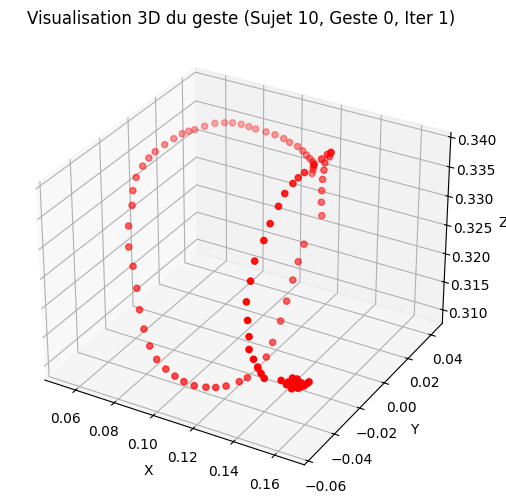


--- Durée moyenne des gestes (s) ---
gesture
0    3980.0
1    3567.2
2    2570.5
3    4037.7
4    3087.1
5    5395.7
6    4499.0
7    4250.9
8    2463.7
9    3477.0
Name: duration, dtype: float64


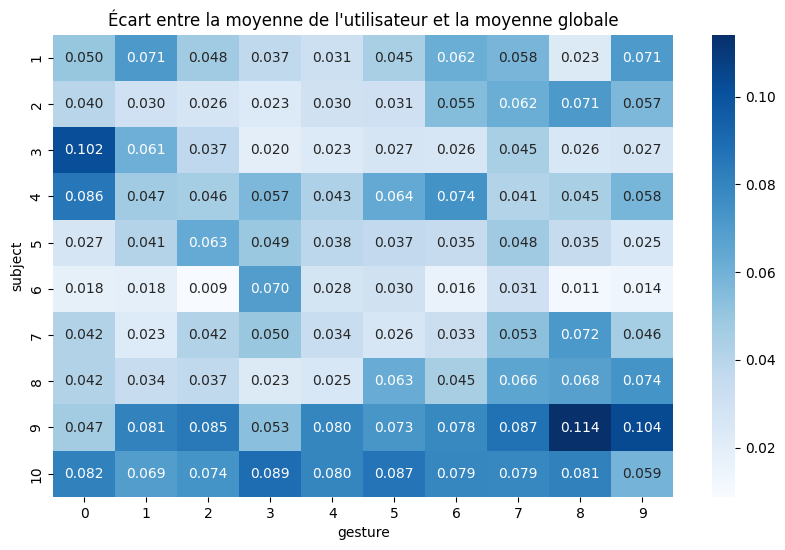

Standardisation...


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_14072\894795356.py:104: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling...

--- Test Split OUT : 1 ---
Précision split 1 : 100.00%

--- Test Split OUT : 2 ---
Précision split 2 : 98.00%

--- Test Split OUT : 3 ---
Précision split 3 : 95.00%

--- Test Split OUT : 4 ---
Précision split 4 : 100.00%

--- Test Split OUT : 5 ---
Précision split 5 : 97.00%

--- Test Split OUT : 6 ---
Précision split 6 : 94.00%

--- Test Split OUT : 7 ---
Précision split 7 : 97.00%

--- Test Split OUT : 8 ---
Précision split 8 : 94.00%

--- Test Split OUT : 9 ---
Précision split 9 : 99.00%

--- Test Split OUT : 10 ---
Précision split 10 : 97.00%

Précision GLOBALE : 97.10%


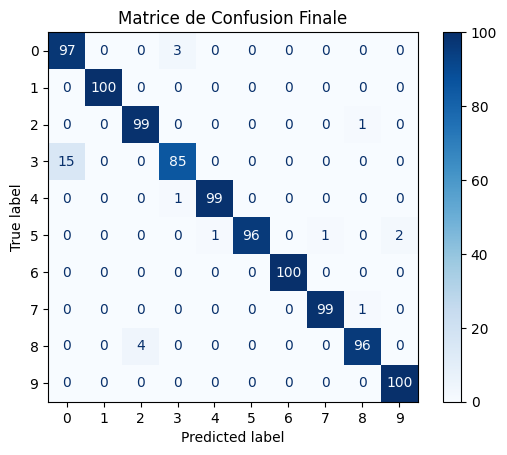

In [2]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import interp1d
import seaborn as sns



DOMAIN_FOLDER =r"\\student.fucam.ac.be\users$\isadiki\Downloads\Domain2base\DOMAIN2_CSVcorrigé"

df_list = []

print("--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:

                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue


                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])


                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)


                file_df['gesture'] = int(number)
                file_df['subject'] = int(subject)
                file_df['iter'] = int(iteration)

                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(" Aucun fichier chargé. Vérifiez le chemin : " + DOMAIN_FOLDER)

df = pd.concat(df_list, ignore_index=True)
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)





subdf = df.loc[(df['gesture'] == 0) & (df['subject'] == 10) & (df['iter'] == 1)]

if not subdf.empty:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(subdf['x'], subdf['y'], subdf['z'], c='red', s=20)
    ax.set_title("Visualisation 3D du geste (Sujet 10, Geste 0, Iter 1)")
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    plt.show()




durations = df.groupby(['gesture', 'iter'])['t'].agg(lambda x: x.max() - x.min()).reset_index(name='duration')
mean_durations = durations.groupby('gesture')['duration'].mean()
print("\n--- Durée moyenne des gestes (s) ---")
print(mean_durations)


mean_coords_user = df.groupby(['subject', 'gesture'])[['x', 'y', 'z']].mean().reset_index()
mean_coords_global = df.groupby('gesture')[['x', 'y', 'z']].mean().reset_index().rename(
    columns={'x':'x_global', 'y':'y_global', 'z':'z_global'})

merged = pd.merge(mean_coords_user, mean_coords_global, on='gesture')
merged['dist_to_global'] = np.sqrt((merged['x']-merged['x_global'])**2 +
                                   (merged['y']-merged['y_global'])**2 +
                                   (merged['z']-merged['z_global'])**2)

pivot = merged.pivot(index='subject', columns='gesture', values='dist_to_global')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap='Blues')
plt.title("Écart entre la moyenne de l'utilisateur et la moyenne globale")
plt.show()



def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)



def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]



def dict_creation_userout(df, subj_out):
    test_df = df[df["subject"] == subj_out]
    train_df = df[df["subject"] != subj_out]

    dict_train = defaultdict(list)
    dict_test = defaultdict(list)

    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())
    for (g, s, it), group in test_df.groupby(["gesture", "subject", "iter"]):
        dict_test[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())
    return dict_train, dict_test

def testmodel(DictCreationFunc, df, loop_range=10, k=5):
    total_true, total_pred = [], []
    for i in range(1, loop_range + 1):
        print(f"\n--- Test Split OUT : {i} ---")
        coord_train, coord_test = DictCreationFunc(df, i)
        y_true, y_pred = [], []
        for gesture, sequences in coord_test.items():
            for seq in sequences:
                pred = knn_dtw_predict(seq, coord_train, k=k)
                y_true.append(gesture)
                y_pred.append(pred)

        acc = accuracy_score(y_true, y_pred)
        total_true.extend(y_true); total_pred.extend(y_pred)
        print(f"Précision split {i} : {acc:.2%}")

    print(f"\nPrécision GLOBALE : {accuracy_score(total_true, total_pred):.2%}")
    cm = confusion_matrix(total_true, total_pred)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues")
    plt.title("Matrice de Confusion Finale")
    plt.show()


testmodel(dict_creation_userout, df100, loop_range=10, k=5)

# lstm final 256 32 32

 Décompression terminée !
--- Début du Chargement du Dossier : /content/temp_data/DOMAIN2_CSVcorrig├й ---


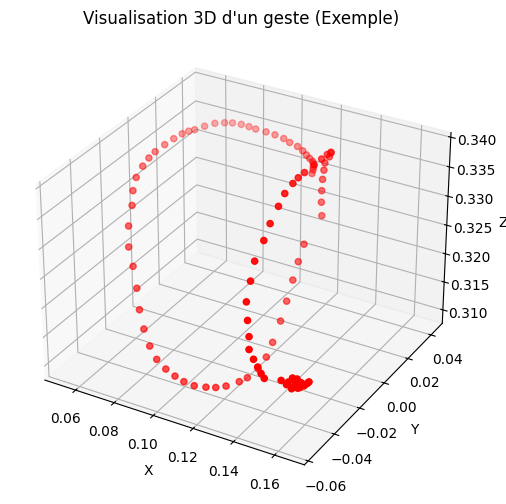


--- Durée moyenne des gestes (s) ---
gesture
0    2959.31
1    2561.69
2    1710.08
3    2756.28
4    2327.70
5    3535.46
6    3282.04
7    3021.08
8    1584.05
9    2563.66
Name: duration, dtype: float64


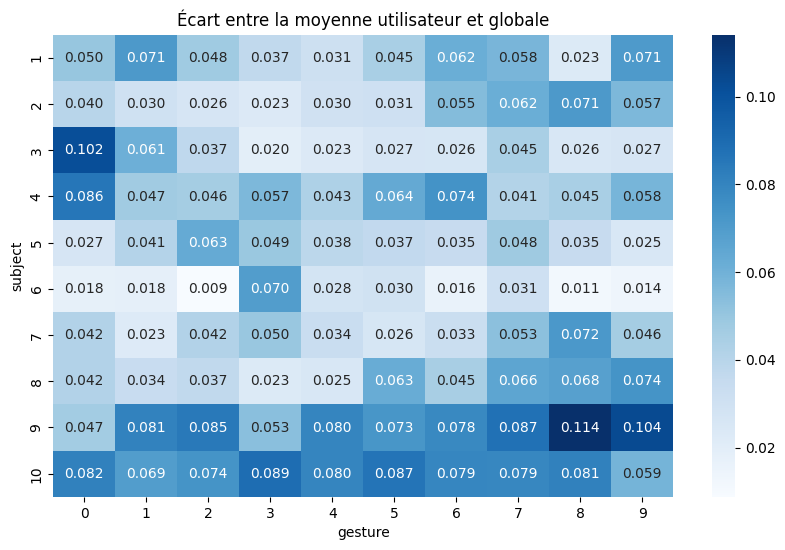


Standardisation en cours...


/tmp/ipykernel_12835/2941902558.py:111: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling à longueur fixe (100 frames)...

--- Entraînement : Sujet 1 en TEST ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Précision pour le sujet 1 : 95.00%

--- Entraînement : Sujet 2 en TEST ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


KeyboardInterrupt: 

In [14]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import seaborn as sns
from tensorflow.keras import models, layers

# --- 1. PRÉPARATION DES FICHIERS (GOOGLE COLAB) ---
# Assure-toi d'avoir uploadé le fichier 'DOMAIN3_CSVcorrigé.zip' dans ton espace Colab
!unzip -o -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
print(" Décompression terminée !")

# --- 2. DÉTECTION AUTOMATIQUE DU DOSSIER ---
base_path = "/content/temp_data"
contenu = os.listdir(base_path)
if len(contenu) > 0:
    # On cherche le dossier qui contient les fichiers (parfois le zip crée un sous-dossier)
    DOMAIN_FOLDER = os.path.join(base_path, contenu[0])
else:
    raise ValueError("Le dossier temp_data est vide. Vérifiez l'upload du ZIP.")

# --- 3. CHARGEMENT DES DONNÉES ---
df_list = []
print(f"--- Début du Chargement du Dossier : {DOMAIN_FOLDER} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture en sautant les lignes d'en-tête inutiles
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2:
                    continue

                # Nettoyage des guillemets et split des colonnes
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion numérique
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')

                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df['gesture'] = int(number)
                file_df['subject'] = int(subject)
                file_df['iter'] = int(iteration)

                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier trouvé. Vérifiez le nom du ZIP ou la structure des dossiers.")

df = pd.concat(df_list, ignore_index=True)


# --- 4. ANALYSE EXPLORATOIRE & VISUALISATION ---

# A. Visualisation 3D d'un geste (Sujet 10, Geste 0, Iter 1)
subdf = df.loc[(df['gesture'] == 0) & (df['subject'] == 10) & (df['iter'] == 1)]
if not subdf.empty:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(subdf['x'], subdf['y'], subdf['z'], c='red', s=20)
    ax.set_title("Visualisation 3D d'un geste (Exemple)")
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    plt.show()

# B. Durée moyenne des gestes
durations = df.groupby(['gesture', 'iter', 'subject'])['t'].agg(lambda x: x.max() - x.min()).reset_index(name='duration')
mean_durations = durations.groupby('gesture')['duration'].mean()
print("\n--- Durée moyenne des gestes (s) ---")
print(mean_durations)

# C. Heatmap des écarts
mean_coords_user = df.groupby(['subject', 'gesture'])[['x', 'y', 'z']].mean().reset_index()
mean_coords_global = df.groupby('gesture')[['x', 'y', 'z']].mean().reset_index().rename(
    columns={'x':'x_global', 'y':'y_global', 'z':'z_global'})

merged = pd.merge(mean_coords_user, mean_coords_global, on='gesture')
merged['dist_to_global'] = np.sqrt((merged['x']-merged['x_global'])**2 +
                                   (merged['y']-merged['y_global'])**2 +
                                   (merged['z']-merged['z_global'])**2)

pivot = merged.pivot(index='subject', columns='gesture', values='dist_to_global')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap='Blues')
plt.title("Écart entre la moyenne utilisateur et globale")
plt.show()

# --- 5. PRÉ-TRAITEMENT (STANDARDISATION & RESAMPLING) ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        if std == 0 or np.isnan(std):
            df_copy[f'{axis}_std'] = 0.0
        else:
            df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std
    return df_copy

print("\nStandardisation en cours...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling à longueur fixe (100 frames)...")
df100 = resample_gesture(df)

# --- 6. ARCHITECTURE DU MODÈLE LSTM ---

def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 7. ÉVALUATION USER-INDEPENDENT (Leave-One-Subject-Out) ---

def test_lstm_user_independent(df_data, epochs=50, batch_size=32):
    total_true, total_pred = [], []
    subjects = sorted(df_data['subject'].unique())
    num_classes = int(df_data['gesture'].max() + 1)

    for subj_out in subjects:
        print(f"\n--- Entraînement : Sujet {subj_out} en TEST ---")

        # Split Train / Test
        train_df = df_data[df_data['subject'] != subj_out]
        test_df = df_data[df_data['subject'] == subj_out]

        def df_to_array(df_target):
            X, y = [], []
            for (g, s, it), group in df_target.groupby(['gesture', 'subject', 'iter']):
                X.append(group[['x_std', 'y_std', 'z_std']].values)
                y.append(g)
            return np.array(X), np.array(y)

        X_train, y_train = df_to_array(train_df)
        X_test, y_test = df_to_array(test_df)

        # Création et entraînement
        model = create_lstm_model(input_shape=(X_train.shape[1], X_train.shape[2]), num_classes=num_classes)
        model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)

        # Prédiction
        y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        acc = accuracy_score(y_test, y_pred)
        print(f"Précision pour le sujet {subj_out} : {acc:.2%}")

        total_true.extend(y_test)
        total_pred.extend(y_pred)

    # Résultat Final
    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n🚀 PRÉCISION GLOBALE LSTM : {final_acc:.2%}")

    # Matrice de Confusion
    cm = confusion_matrix(total_true, total_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Matrice de Confusion Finale (LSTM)")
    plt.ylabel('Vrai Geste')
    plt.xlabel('Geste Prédit')
    plt.show()

# Lancement du test final
test_lstm_user_independent(df100)